# Area Dropdown Notebook

Futures Notebook 


The purpose of this notebook is to:

1) Provide concise and targeted support for future landscape planning from opensource and Living Wales datasets.
2) Assess the value of habitats within the site based on current interests.
3) Develop a method to monitor the site's progress towards a pre-planned future scenario. 

For part 3 of this notebook, a future plan for the site in LCCS classification is required. For detailed guidance on creating this plan, please visit the Living Wales website at Living Earth Hub.


*Looking for: 
- every output from the Area selection needs to have a generic name aka 'boundary'
- simplified dropdown selection 
- Draw an area not working
- Get the past and present plots working 
- Get statistics from each plot*
- map at time1 and time2. display in a a singe row of 3. map time1, map time2 AND map showing difference highlighted in red (also show a table of what became what) 

# 0. Load initial datasets and functions

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import glob

import pyproj
from pyproj import CRS

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import datacube
from datacube.utils.geometry import Geometry, CRS

import ipyleaflet
from ipyleaflet import Map, GeoData, LayersControl, FullScreenControl, basemaps

import ipywidgets as widgets
from ipywidgets import Layout, HTML, VBox, Dropdown, BoundedFloatText, HBox, Button

import matplotlib.colors as colors 
from matplotlib.colors import ListedColormap, BoundaryNorm


# from
from IPython.display import display, clear_output
from shapely.geometry import shape
from shapely.ops import transform


from odc.ui import with_ui_cbk
#from odc.geo import datacube_ows as dc_ows


sys.path.append("/home/jovyan/notebooks/wales_utils/data_cube_utilities")
from display_tools import map_geom, rgb, draw_select
from wdc_datahandling import geopolygon_masking, geom_fromdrawn

import notebook_dropdowns

# 1. AREA selection - (AREA_SELECTION)

## 1.1. WELSH DATASETS - (A) Select by name

In [2]:
get_type, get_shapefile, get_polygon, reset_button = notebook_dropdowns.area_selection()
display(get_type)
display(get_shapefile)
display(get_polygon)
display(reset_button)

Dropdown(description='Type', options=('1. User uploads', '2. Draw an area', 'NRW forest legal boundaries', 'SS…

Dropdown(description='Vector', options=('bbnp boundary', 'blackmts boundary', 'blackmts fields', 'llangorse bo…

Dropdown(description='Select a polygon', options=(), value=None)

Button(description='Reset', style=ButtonStyle())

### Check the site boundary visually and by area

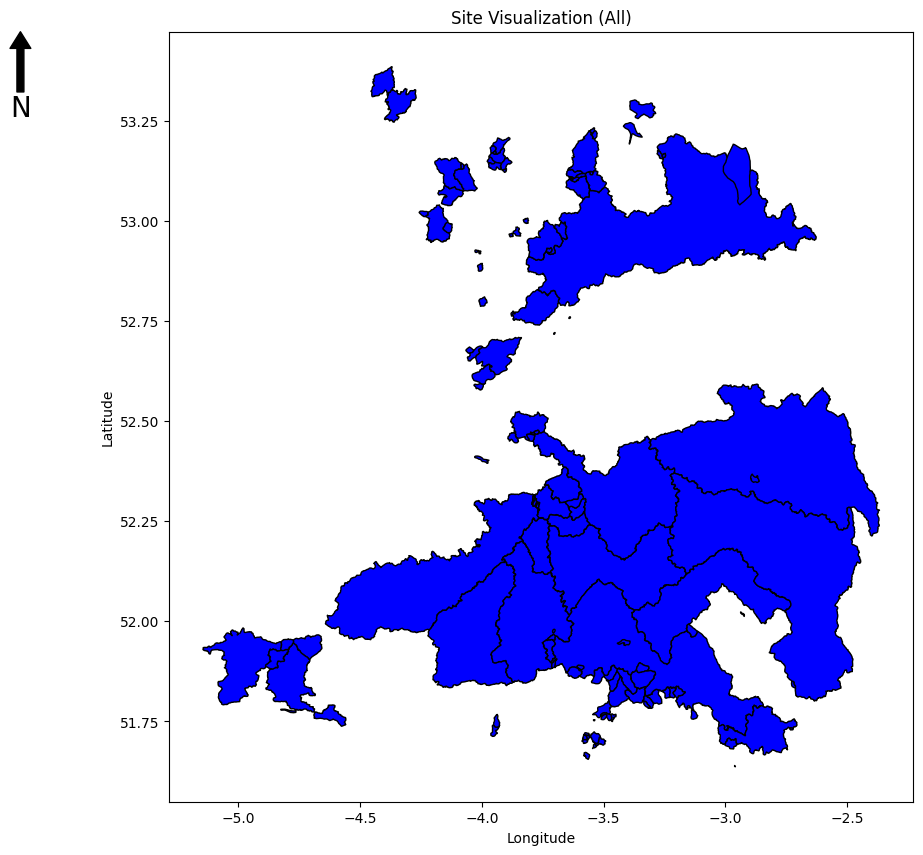

Total area: 2923566.23 ha


In [3]:
gpd_df_sub = notebook_dropdowns.static_polygon_plot(get_polygon)

### Visualise on a map and CONFIRM

In [4]:
notebook_dropdowns.interactive_polygon_plot(gpd_df_sub)

In [ ]:
notebook_dropdowns.selected_polygon

## 1.1. WELSH DATASETS - (B) Select on a map

### Check the site boundary visually and by area

### Visualise on a map and make your selection

### Display selected polygon

In [ ]:
import geopandas as gpd
from ipyleaflet import GeoData, Map, LayersControl, FullScreenControl, basemaps
from ipywidgets import Layout, VBox, HTML, Button
from IPython.display import display

# Function to visualize the selected polygon on a new map
def visualize_selected_polygon(selected_polygon):
    if selected_polygon:
        global selected_gdf  # Declare as global to update later
        selected_gdf = shapefile_plots[shapefile_plots.apply(lambda row: all(selected_polygon[k] == row[k] for k in selected_polygon), axis=1)]
        
        selected_geo_data = GeoData(
            geo_dataframe=selected_gdf,
            style={
                "color": "black",
                "fillColor": "#3366cc",
                "opacity": 0.05,
                "weight": 1.9,
                "dashArray": "2",
                "fillOpacity": 0.6,
            },
            hover_style={"fillColor": "red", "fillOpacity": 0.2},
            name="Selected Polygon",
        )
        
        # Calculate the center of the selected polygon
        bounds = selected_gdf.total_bounds  # returns (minx, miny, maxx, maxy)
        center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
        
        # Create a map centered on the selected polygon
        selected_map = Map(center=center, zoom=10, basemap=basemaps.Esri.WorldImagery, layout=Layout(height='600px'))
        
        # Add GeoData layer to the map
        selected_map.add_layer(selected_geo_data)
        
        # Fit map to bounds
        sw = [bounds[1], bounds[0]]  # southwest corner (miny, minx)
        ne = [bounds[3], bounds[2]]  # northeast corner (maxy, maxx)
        selected_map.fit_bounds([sw, ne])
        
        # Add controls to the map
        selected_map.add_control(LayersControl(position='topright'))
        selected_map.add_control(FullScreenControl())
        
        # Display the map
        display(selected_map)

# Function to confirm and rename the output to AREA_selection
def confirm_selection(button):
    global AREA_selection
    AREA_selection = selected_gdf
    print("The selected area has been confirmed as AREA_selection")

# Create a button for confirming the selection
confirm_button = Button(description="CONFIRM")
confirm_button.on_click(confirm_selection)

# Display the instructions, button, and map
instructions = HTML("<b>If you are happy with this AREA please confirm before continuing</b>")
display(instructions)
display(confirm_button)

# Example: Visualize the selected polygon stored in 'selected_polygon' from PART 3
visualize_selected_polygon(selected_polygon)


## 1.2. UPLOAD SHAPEFILE

This is the uploads folder > INSERT


For more information on how to do this please refer to INSERT LINK TO RELEVANT NOTEBOOK 

*N.B A shapefile is used to define the area of interest. Within the 'vectors' folder there is an example shape file for the BBNP (`habstat_Boundary.*`) you can use this or upload one of your personal datasets. If you are using the example then download to your machine from the folder view and upload to the `uploads` folder. You must upload all of the files associated with the shapefile. Add the name to the code below*


In [ ]:
# PART1
# Function to update the shapefile options
def update_shapefiles(*args):
    # List all shapefiles in the selected directory
    shapefiles_list = glob.glob(os.path.join(vector_types_dict[get_type.value], "*.shp"))
    shapefiles_dict.clear()
    shapefiles_dict.update({os.path.basename(shapefile).replace(".shp", "").replace("_", " ").lower(): shapefile for shapefile in shapefiles_list})
    
    # Update shapefile dropdown options
    get_shapefile.options = list(shapefiles_dict.keys())
    get_shapefile.value = list(shapefiles_dict.keys())[0] if shapefiles_dict else None
    update_polygons()

# Function to update the polygon options
def update_polygons(*args):
    selected_shapefile_path = shapefiles_dict.get(get_shapefile.value, None)
    
    if selected_shapefile_path:
        global gpd_df, col_name_var  # Define as global variables
        gpd_df = gpd.read_file(selected_shapefile_path)
        
        # Try to find a suitable column name for site names
        col_name_var = None
        if "name" in gpd_df.columns:
            col_name_var = "name"
        else:
            for col in gpd_df.columns:
                if "name" in col.lower():
                    col_name_var = col
                    break

        if col_name_var is not None:
            site_names = gpd_df[col_name_var].drop_duplicates().tolist()
            get_polygon.options = site_names
            get_polygon.value = site_names[0] if site_names else None
        else:
            get_polygon.options = []
            get_polygon.value = None
    else:
        get_polygon.options = []
        get_polygon.value = None

# Path to Welsh Dataset repository
vector_types_list = glob.glob("/home/jovyan/shared_space/uploads/") #put/*/* to move up the file directry
vector_types_dict = {os.path.basename(vector_type).replace("_", " "): vector_type for vector_type in vector_types_list if os.path.isdir(vector_type)}

shapefiles_dict = {}

# Dropdown for selecting vector type
get_type = widgets.Dropdown(
    options=list(vector_types_dict.keys()),
    value=list(vector_types_dict.keys())[0],
    description="Type",
    disabled=False,
)

# Dropdown for selecting shapefile
get_shapefile = widgets.Dropdown(
    options=[],
    description="Vector",
    disabled=False,
)

# Dropdown for selecting polygon
get_polygon = widgets.Dropdown(
    options=[],
    description="Select a polygon",
    disabled=False,
)

# Observe changes and update accordingly
get_type.observe(update_shapefiles, 'value')
get_shapefile.observe(update_polygons, 'value')

# Function to reset the dropdowns and clear outputs
def reset_dropdowns(*args):
    get_type.value = list(vector_types_dict.keys())[0]
    update_shapefiles()
    clear_output(wait=True)
    display(get_type)
    display(get_shapefile)
    display(get_polygon)
    display(reset_button)

# Button for resetting the dropdowns
reset_button = widgets.Button(description="Reset")
reset_button.on_click(reset_dropdowns)

# Display the dropdowns and reset button
display(get_type)
display(get_shapefile)
display(get_polygon)
display(reset_button)

# Initial update of shapefiles and polygons
update_shapefiles()


In [ ]:
#PART2
if col_name_var is not None and get_polygon.value is not None:
    gpd_df_sub = gpd_df[gpd_df[col_name_var] == get_polygon.value]
else:
    gpd_df_sub = gpd_df
    
# Ensure the GeoDataFrame is in a projected CRS for accurate area calculation
gpd_df_sub = gpd_df_sub.to_crs(epsg=3857)

# Calculate the area in square meters
gpd_df_sub['area'] = gpd_df_sub.geometry.area

# Sum the areas to get the total area in hectares (1 hectare = 10,000 square meters)
total_area = gpd_df_sub['area'].sum() / 10000

# Set the GeoDataFrame back to geographic CRS for plotting
gpd_df_sub = gpd_df_sub.to_crs(epsg=4326)

# Set the figure size for standardization
fig, ax = plt.subplots(figsize=(10, 10))

# Visualize the polygon with standardized size
gpd_df_sub.plot(ax=ax, color='blue', edgecolor='black')
ax.set_title('Site Visualization')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add north arrow
x, y = -0.2, 1  # Adjust these values based on your plot
arrow_length = 0.1
ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=20,
            xycoords='axes fraction')

plt.show()

# Display total area
print(f"Total area: {total_area:.2f} ha")

### Visualise on a map and confirm

In [ ]:
import geopandas as gpd
from ipyleaflet import GeoData, Map, LayersControl, FullScreenControl, basemaps
from ipywidgets import Layout, VBox, HTML, Button
from IPython.display import display

# Part 3
# Function to convert Timestamps to strings
def convert_timestamps_to_strings(df):
    """
    Converts all Timestamp columns in the DataFrame to strings.
    """
    for col in df.columns:
        # Comment out print to debug
        # print(f"{col} {df[col].dtype}")
        if isinstance(df[col].dtype, pd.core.dtypes.dtypes.DatetimeTZDtype) or df[col].dtype == 'datetime64[ns]' or df[col].dtype == 'datetime64[ms]':
            df[col] = df[col].astype(str)
    return df

# Calculate the bounding box
bounds = gpd_df_sub.total_bounds  # returns (minx, miny, maxx, maxy)
sw = [bounds[1], bounds[0]]  # southwest corner (miny, maxx)
ne = [bounds[3], bounds[2]]  # northeast corner (maxy, minx)

# Calculate the center of the bounding box
center = [(sw[0] + ne[0]) / 2, (sw[1] + ne[1]) / 2]

# Convert any Timestamps to strings
AREA_selection = convert_timestamps_to_strings(gpd_df_sub)

# Function to confirm and rename the output to AREA_selection
def confirm_selection(button):
    global AREA_selection
    AREA_selection = AREA_selection
    print("The selected area has been confirmed as AREA_selection")

# Create a button for confirming the selection
confirm_button = Button(description="CONFIRM")
confirm_button.on_click(confirm_selection)

# Display the instructions, button, and map
instructions = HTML("<b>If you are happy with this AREA please confirm before continuing</b>")
display(VBox([instructions, confirm_button]))

# Create GeoData layer
geo_data = GeoData(
    geo_dataframe=AREA_selection,
    style={
        "color": "black",
        "fillColor": "#3366cc",
        "opacity": 0.05,
        "weight": 1.9,
        "dashArray": "2",
        "fillOpacity": 0.6,
    },
    hover_style={"fillColor": "red", "fillOpacity": 0.2},
    name="Boundary",
)

# Create a map centered on the GeoDataFrame
m = Map(center=center, zoom=50, basemap=basemaps.Esri.WorldImagery, layout=Layout(height='600px'))

# Add GeoData layer to the map
m.add_layer(geo_data)

# Fit map to bounds
m.fit_bounds([sw, ne])

# Add controls to the map
m.add_control(LayersControl(position='topright'))
m.add_control(FullScreenControl())

# Display the map
display(m)


## 1.3. DRAW AN AREA

For more information on how to do this please refer to INSERT LINK TO RELEVANT NOTEBOOK 

In [ ]:
# Selecting an area within Wales

file_name = "Wales_boundary"
area_name = "Wales_area"


# Open and read the shapefiles
boundary_path = f"/home/jovyan/shared_space/welsh_areas/wales_boundary/{file_name}.shp"
boundary_exists = os.path.isfile(boundary_path)


if boundary_exists:
    boundary = gpd.read_file(boundary_path)
else:
    print("Could not find file, please check the name")
    print(os.listdir("../uploads/"))
    
boundary.head(3)

geom = Geometry(geom=boundary.iloc[0].geometry, crs=CRS("epsg:27700"))
geom

In [ ]:
import geopandas as gpd
from ipyleaflet import Map, GeoData, LayersControl, FullScreenControl, DrawControl, basemaps
from ipywidgets import Layout, VBox, HTML
from IPython.display import display

# Function to handle area selection
def handle_draw(self, action, geo_json):
    global selected_area
    selected_area = geo_json['geometry']
    html.value = f"Selected area: {selected_area}"
    print(f"Selected area: {selected_area}")  # Debugging statement

# Load the shapefile dataset
boundary_path = f"/home/jovyan/shared_space/welsh_areas/wales_boundary/{file_name}.shp"
boundary = gpd.read_file(boundary_path)

# Ensure the GeoDataFrame is in the correct CRS for display
boundary = boundary.to_crs(epsg=4326)

# HTML widget to display selected area information
html = HTML()
html.value = "Draw an area to select it."

# Create GeoData layer for the boundary
geo_data = GeoData(
    geo_dataframe=boundary,
    style={'color': 'red', 'fillColor': 'none', 'opacity': 1, 'weight': 2},
    name='Boundary'
)

# Create a map centered on the boundary with appropriate zoom
bounds = boundary.total_bounds  # returns (minx, miny, maxx, maxy)
center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
m = Map(center=center, zoom=8, basemap=basemaps.Esri.WorldImagery, layout=Layout(height='600px'))

# Add GeoData layer to the map
m.add_layer(geo_data)

# Add drawing tools to the map
draw_control = DrawControl(
    polygon={"shapeOptions": {"color": "#ff0000", "weight": 4}},
    polyline={"shapeOptions": {"color": "#ff0000", "weight": 4}},
    circle={"shapeOptions": {"color": "#ff0000", "weight": 4}},
    rectangle={"shapeOptions": {"color": "#ff0000", "weight": 4}},
    marker={"shapeOptions": {"color": "#ff0000", "weight": 4}}
)

draw_control.on_draw(handle_draw)
m.add_control(draw_control)

# Add controls to the map
m.add_control(LayersControl(position='topright'))
m.add_control(FullScreenControl())

# Display the initial map with the HTML widget
display(VBox([html, m]))

# Initialize selected_area variable
selected_area = None


### Display selection

In [ ]:
import geopandas as gpd
from ipyleaflet import Map, GeoData, LayersControl, FullScreenControl, basemaps
from ipywidgets import Layout, HTML, VBox, Button
from IPython.display import display
from shapely.geometry import shape
from shapely.ops import transform
import pyproj

# Function to visualize the selected area on a new map
def visualize_selected_area(selected_area):
    global AREA_selection  # Declare global variable for AREA_selection

    if selected_area:
        # Convert the selected area to a GeoDataFrame
        selected_geom = shape(selected_area)
        selected_gdf = gpd.GeoDataFrame({'geometry': [selected_geom]}, crs='epsg:4326')
        
        # Calculate the area in hectares
        proj = pyproj.Transformer.from_crs('epsg:4326', 'epsg:3857', always_xy=True).transform
        selected_gdf['area_ha'] = selected_gdf['geometry'].apply(lambda geom: transform(proj, geom).area / 10000)
        area_ha = selected_gdf['area_ha'].iloc[0]
        
        # Transform shapefile boundaries into geographic data (and affect a style)
        geo_data = GeoData(
            geo_dataframe=selected_gdf,
            style={
                "color": "black",
                "fillColor": "#3366cc",
                "opacity": 0.05,
                "weight": 1.9,
                "dashArray": "2",
                "fillOpacity": 0.6,
            },
            hover_style={"fillColor": "red", "fillOpacity": 0.2},
            name="Selected Area",
        )
        
        # Calculate the center of the selected area
        bounds = selected_gdf.total_bounds  # returns (minx, miny, maxx, maxy)
        center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
        
        # Create a map centered on the selected area
        selected_map = Map(center=center, zoom=10, basemap=basemaps.Esri.WorldImagery, layout=Layout(height='600px'))
        
        # Add GeoData layer to the map
        selected_map.add_layer(geo_data)
        
        # Fit map to bounds
        sw = [bounds[1], bounds[0]]  # southwest corner (miny, minx)
        ne = [bounds[3], bounds[2]]  # northeast corner (maxy, maxx)
        selected_map.fit_bounds([sw, ne])
        
        # Add controls to the map
        selected_map.add_control(LayersControl(position='topright'))
        selected_map.add_control(FullScreenControl())
        
        # Function to confirm and rename the output to AREA_selection
        def confirm_selection(button):
            global AREA_selection
            AREA_selection = selected_gdf
            display(HTML("<b>The selected area has been confirmed as AREA_selection</b>"))

        # Create a button for confirming the selection
        confirm_button = Button(description="CONFIRM")
        confirm_button.on_click(confirm_selection)

        # Display the map, button, and area in hectares
        display(VBox([HTML("<b>If you are happy with this AREA please confirm before continuing</b>"), confirm_button, selected_map, HTML(f"Selected area: {area_ha:.2f} hectares")]))
    else:
        display(HTML("No area selected."))

# Example: Visualize the selected area stored in 'selected_area' from PART 2
visualize_selected_area(selected_area)


## 1.4. Add a Buffer - (A) including/around your site

In [ ]:
from ipywidgets import RadioButtons, BoundedFloatText, HBox, VBox, Button, Layout
from IPython.display import display

# Global variable for buffer distance
buffer_distance = 100

# Function to handle buffer distance selection
def on_buffer_distance_change(change):
    global buffer_distance
    if change['new'] == 'CUSTOM':
        custom_buffer_distance.layout.display = ''  # Show custom distance input
    else:
        custom_buffer_distance.layout.display = 'none'  # Hide custom distance input
        buffer_distance = change['new']

# Function to handle custom buffer distance input
def on_custom_buffer_distance_change(change):
    global buffer_distance
    buffer_distance = change['new'] * 1000  # Convert km to meters

# Function to confirm buffer distance selection
def on_confirm_button_clicked(b):
    global confirmed_buffer_distance
    confirmed_buffer_distance = buffer_distance
    display(f"Buffer distance set to: {confirmed_buffer_distance} meters")

# Radio buttons widget for selecting buffer distance
buffer_distance_options = RadioButtons(
    options=[('100m', 100), ('500m', 500), ('1km', 1000), ('5km', 5000), ('10km', 10000), ('25km', 25000), ('50km', 50000), ('CUSTOM', 'CUSTOM')],
    value=100,
    description='Buffer Distance:',
    layout=Layout(width='300px')  # Set the width of the widget
)

# Text box for custom buffer distance
custom_buffer_distance = BoundedFloatText(
    value=1,
    min=0.001,
    max=100,
    step=0.1,
    description='Custom (km):',
    layout=Layout(width='200px')  # Set the width of the widget
)
custom_buffer_distance.layout.display = 'none'  # Hide initially

# Button to confirm buffer distance selection
confirm_button = Button(description="Confirm Buffer Distance")
confirm_button.on_click(on_confirm_button_clicked)

# Display widgets
display(VBox([buffer_distance_options, custom_buffer_distance, confirm_button]))

# Observe changes
buffer_distance_options.observe(on_buffer_distance_change, names='value')
custom_buffer_distance.observe(on_custom_buffer_distance_change, names='value')

# Initialize buffer_distance variable
buffer_distance = 100
confirmed_buffer_distance = buffer_distance  # Initialize confirmed buffer distance


In [ ]:
import geopandas as gpd
from ipyleaflet import Map, GeoData, LayersControl, FullScreenControl, basemaps
from ipywidgets import Layout, HTML, VBox, Button
from IPython.display import display
from shapely.geometry import shape
from shapely.ops import transform
import pyproj

# Function to create buffer and display it on a map
def create_and_display_buffer(area_gdf, buffer_distance):
    global AREA_BufferA  # Declare AREA_BufferA as a global variable to store the buffer area
    if area_gdf is not None and not area_gdf.empty:
        # Use the geometry of the first (and only) feature in the GeoDataFrame
        selected_geom = area_gdf.iloc[0].geometry
        
        # Reproject the geometry to EPSG:3857 for buffering in meters
        proj = pyproj.Transformer.from_crs('epsg:4326', 'epsg:3857', always_xy=True).transform
        reprojected_geom = transform(proj, selected_geom)
        
        # Create buffer around the reprojected geometry
        buffer_geom = reprojected_geom.buffer(buffer_distance)
        
        # Reproject the buffer back to EPSG:4326
        proj_back = pyproj.Transformer.from_crs('epsg:3857', 'epsg:4326', always_xy=True).transform
        buffer_geom = transform(proj_back, buffer_geom)
        
        # Convert the buffer to a GeoDataFrame
        AREA_BufferA = gpd.GeoDataFrame({'geometry': [buffer_geom]}, crs='epsg:4326')
        
        # Create GeoData layer for the selected area
        selected_geo_data = GeoData(
            geo_dataframe=area_gdf,
            style={
                "color": "black",
                "fillColor": "#3366cc",
                "opacity": 0.05,
                "weight": 1.9,
                "dashArray": "2",
                "fillOpacity": 0.6,
            },
            hover_style={"fillColor": "red", "fillOpacity": 0.2},
            name="Selected Area",
        )
        
        # Create GeoData layer for the buffer area
        buffer_geo_data = GeoData(
            geo_dataframe=AREA_BufferA,
            style={
                "color": "black",
                "fillColor": "#ffcc00",
                "opacity": 0.5,
                "weight": 1.9,
                "dashArray": "2",
                "fillOpacity": 0.3,
            },
            hover_style={"fillColor": "red", "fillOpacity": 0.2},
            name="Buffer Area",
        )
        
        # Calculate the center of the buffer area
        bounds = AREA_BufferA.total_bounds  # returns (minx, miny, maxx, maxy)
        center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
        
        # Create a map centered on the buffer area
        buffer_map = Map(center=center, zoom=10, basemap=basemaps.Esri.WorldImagery, layout=Layout(height='600px'))
        
        # Add GeoData layers to the map
        buffer_map.add_layer(selected_geo_data)
        buffer_map.add_layer(buffer_geo_data)
        
        # Fit map to bounds
        sw = [bounds[1], bounds[0]]  # southwest corner (miny, minx)
        ne = [bounds[3], bounds[2]]  # northeast corner (maxy, maxx)
        buffer_map.fit_bounds([sw, ne])
        
        # Add controls to the map
        buffer_map.add_control(LayersControl(position='topright'))
        buffer_map.add_control(FullScreenControl())
        
        # Display the map
        display(buffer_map)
    else:
        display(HTML("No area selected."))

# Function to confirm and rename AREA_BufferA to AREA_selection
def confirm_selection(button):
    global AREA_selection
    AREA_selection = AREA_BufferA
    print("AREA_BufferA has been renamed to AREA_selection")

# Create a button for confirming the buffer as the selection
confirm_selection_button = Button(description="CONFIRM")
confirm_selection_button.on_click(confirm_selection)

# Display the instructions, button, and map
instructions = HTML("<b>If you are happy with this buffer and site as your FINAL AREA selection please confirm below. <br>If you would like to remove the site from the buffer please continue to the next step</b>")
display(VBox([instructions, confirm_selection_button]))

# Example: Visualize the selected area and buffer stored in 'AREA_selection' and 'buffer_distance'
create_and_display_buffer(AREA_selection, confirmed_buffer_distance)


## 1.4. Buffer - (B) exclude your site

In [ ]:

# Function to create AREA_BufferB by removing AREA_selection from AREA_BufferA
def create_AREA_BufferB(area_selection, area_bufferA):
    global AREA_BufferB  # Declare AREA_BufferB as a global variable to store the new buffer area
    
    # Get the geometry of AREA_selection and AREA_BufferA
    selection_geom = area_selection.iloc[0].geometry
    bufferA_geom = area_bufferA.iloc[0].geometry
    
    # Perform the difference operation
    bufferB_geom = bufferA_geom.difference(selection_geom)
    
    # Convert the result to a GeoDataFrame
    AREA_BufferB = gpd.GeoDataFrame({'geometry': [bufferB_geom]}, crs='epsg:4326')
    
    # Create GeoData layer for AREA_BufferB
    bufferB_geo_data = GeoData(
        geo_dataframe=AREA_BufferB,
        style={
            "color": "black",
            "fillColor": "#00cc66",
            "opacity": 0.5,
            "weight": 1.9,
            "dashArray": "2",
            "fillOpacity": 0.3,
        },
        hover_style={"fillColor": "red", "fillOpacity": 0.2},
        name="Buffer B Area",
    )
    
    # Calculate the center of the buffer area
    bounds = AREA_BufferB.total_bounds  # returns (minx, miny, maxx, maxy)
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    
    # Create a map centered on the buffer area
    bufferB_map = Map(center=center, zoom=10, basemap=basemaps.Esri.WorldImagery, layout=Layout(height='600px'))
    
    # Add GeoData layer to the map
    bufferB_map.add_layer(bufferB_geo_data)
    
    # Fit map to bounds
    sw = [bounds[1], bounds[0]]  # southwest corner (miny, minx)
    ne = [bounds[3], bounds[2]]  # northeast corner (maxy, maxx)
    bufferB_map.fit_bounds([sw, ne])
    
    # Add controls to the map
    bufferB_map.add_control(LayersControl(position='topright'))
    bufferB_map.add_control(FullScreenControl())
    
    # Display the map
    display(bufferB_map)

# Function to confirm and rename AREA_BufferB to AREA_selection
def confirm_selection(button):
    global AREA_selection
    AREA_selection = AREA_BufferB
    print("AREA_BufferB has been renamed to AREA_selection")

# Create a button for confirming the buffer as the selection
confirm_button = Button(description="CONFIRM")
confirm_button.on_click(confirm_selection)

# Display the instructions, button, and map
instructions = HTML("<b>If you are happy with this buffer and, with the site excluded, as your AREA selection please confirm below</b>")
display(VBox([instructions, confirm_button]))

# Create AREA_BufferB by removing AREA_selection from AREA_BufferA
create_AREA_BufferB(AREA_selection, AREA_BufferA)


# DISPLAY final AREA selection OUTPUT

In [ ]:
# Function to display AREA_selection on a map
def display_AREA_selection(area_selection):
    if not area_selection.empty:
        # Create GeoData layer for AREA_selection
        selection_geo_data = GeoData(
            geo_dataframe=area_selection,
            style={
                "color": "black",
                "fillColor": "#3366cc",
                "opacity": 0.5,
                "weight": 1.9,
                "dashArray": "2",
                "fillOpacity": 0.3,
            },
            hover_style={"fillColor": "red", "fillOpacity": 0.2},
            name="AREA Selection",
        )
        
        # Calculate the center of the selection area
        bounds = area_selection.total_bounds  # returns (minx, miny, maxx, maxy)
        center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
        
        # Create a map centered on the selection area
        selection_map = Map(center=center, zoom=10, basemap=basemaps.Esri.WorldImagery, layout=Layout(height='600px'))
        
        # Add GeoData layer to the map
        selection_map.add_layer(selection_geo_data)
        
        # Fit map to bounds
        sw = [bounds[1], bounds[0]]  # southwest corner (miny, minx)
        ne = [bounds[3], bounds[2]]  # northeast corner (maxy, maxx)
        selection_map.fit_bounds([sw, ne])
        
        # Add controls to the map
        selection_map.add_control(LayersControl(position='topright'))
        selection_map.add_control(FullScreenControl())
        
        # Display the map
        display(selection_map)
    else:
        display(HTML("No area selected."))

# Example: Display the AREA_selection
display_AREA_selection(AREA_selection)
